# Module Investigation
for phase 1 oysters 

Interested to know if there are a subset of genes that drive the relationship we see between modules and factors. Here, I'm going to pull genes within a significantly correlated module and look into their individual GE.

## 0. load libraries

In [2]:
library(tidyverse)
library(pheatmap)

## 1. read csvs

### module genes
generated in [WGCNA](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/wgcna/newRef_wgcna_p1.ipynb) for phase 1 oysters

In [3]:
geneInfo <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/wgcna/outputs/p1.wgcna_GeneInfo.csv')
head(geneInfo)

,Gene,GO.terms,ModuleColor,GS.ambient,GS.normoxic,phase1_treatment.GS.control,phase1_treatment.GS.hypoxic,phase1_treatment.GS.warm,p.GS.ambient,p.GS.normoxic,⋯,MMblue,MMgreenyellow,MMyellow,MMblack,MMbrown,MMpink,MMmagenta,MMtan,MMgreen,MMred
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,blue,-0.385003047,0.02872849,-0.2866151,-0.15136167,0.3192964,0.06966152,0.896471463,⋯,0.3336787,0.09526861,-0.03750345,-0.01178296,-0.04856269,0.11541601,-0.46324802,-0.19648759,0.05033161,-0.04085780
2,LOC111099037,GO:0000978;GO:0000981;GO:0006355,black,0.363072643,0.28138410,0.5014935,-0.08846465,-0.1813930,0.08860508,0.193366725,⋯,-0.2452065,-0.14257739,-0.16774119,0.34293007,0.31439017,-0.06523956,0.07719107,-0.15380042,0.22565913,0.02356195
3,LOC111099039,GO:0004930;GO:0005886;GO:0007189,blue,-0.221972568,0.34604876,0.1006079,-0.35312230,0.2930547,0.30870243,0.105776904,⋯,0.1248501,0.26055230,0.01693705,0.20241978,0.34095291,0.00285947,-0.37935688,-0.49934818,0.05801010,-0.35374473
4,LOC111099041,GO:0016020;GO:0022857;GO:0055085,red,-0.004370064,-0.34594159,-0.1025999,0.09762852,-0.2909408,0.98421142,0.105892223,⋯,-0.4530072,-0.51091263,-0.31182848,-0.07876547,0.07063991,0.36582448,0.50638260,0.32368892,0.40288267,0.68022795
5,LOC111099050,GO:0005515;GO:0006886;GO:0031462;GO:0043161;GO:1990756,green,0.254057873,-0.06198487,0.2008223,0.08819213,-0.2713359,0.24208590,0.778740020,⋯,-0.3888532,-0.68292735,-0.49529157,0.14867299,0.47087567,-0.25366995,0.40577512,0.03737519,0.72387889,0.49103456
6,LOC111099053,GO:0001731;GO:0003729;GO:0003743;GO:0005850;GO:0006413;GO:0031369,blue,-0.370840965,0.54214175,0.1000841,-0.52195012,0.5166526,0.08150055,0.007531461,⋯,0.7387194,0.17197754,0.25907960,0.07602427,-0.20551233,-0.60202609,-0.33485346,-0.05929480,-0.20905791,-0.29068174


### vst
generated in [DESeq analysis](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/filter_deseq_p1.v.p1.ipynb) for phase 1 oysters

In [4]:
vst <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res/prefilter_deseq/p1_vst.csv')
head(vst)

,X,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,11.217975,11.934767,11.224763,11.385998,11.491494,11.330413,11.619094,11.599610,10.935631,⋯,11.695721,11.157977,11.658281,11.998989,11.369555,11.484610,11.158177,11.698655,11.463655,11.597431
2,LOC144621269,9.238570,14.233747,13.248661,6.734822,7.542979,13.067731,11.252050,11.655097,11.695209,⋯,13.172456,11.238048,8.354464,15.534626,13.113269,11.584691,11.875265,13.441989,6.077703,12.341027
3,LOC111120925,6.162650,6.596958,6.709412,6.097391,6.365111,6.642652,8.868688,8.893482,8.281309,⋯,8.933040,6.529973,8.449891,8.330386,6.304683,8.790027,6.259740,6.294474,5.806396,6.516750
4,LOC144621283,9.891478,10.157309,10.265604,9.957131,10.370479,10.049745,9.730975,10.158138,10.091135,⋯,10.091122,9.802983,9.406153,9.831201,9.297184,10.572628,10.579026,9.655386,10.115723,10.146704
5,LOC144621276,13.540965,13.766144,14.145528,13.224735,13.084951,13.044656,13.810034,13.596797,13.309595,⋯,13.929735,13.686105,12.877924,13.996777,12.961637,13.892552,14.181140,13.333327,13.928741,13.550413
6,LOC111115920,8.717293,8.463000,8.350118,8.954966,9.308119,8.469442,7.913170,8.149178,8.357417,⋯,7.567075,8.159515,8.690883,8.016850,7.795664,8.011123,8.435333,8.088760,8.136625,7.770861


### meta data

In [20]:
growth <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/growth_phase1_weights.csv')

# need to convert sample names to be consistent with my naming convention
growth$Sample <- paste0(substr(growth$Phase_1_treat, 1, 1), growth$Phase_1_rep, '_Nu_', growth$Tag_color, growth$Tag_num)

growth <- growth %>% select(Sample, 
                            Phase_1_treat, 
                            Phase_1_temp, 
                            Phase_1_DO, 
                            Actual_tissue_growth_mg, 
                            Actual_shell_growth_mg, 
                            Ratio_tissue_shell_mg)

head(growth)

,Sample,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,B1_Nu_O1,Both,Warm,Hyp,21.92322,42.27678,0.518564091
2,B1_Nu_O2,Both,Warm,Hyp,42.34732,63.65268,0.665287306
3,B1_Nu_O3,Both,Warm,Hyp,27.91340,77.58660,0.359770888
4,B1_Nu_O4,Both,Warm,Hyp,148.21004,157.38996,0.941674043
5,B1_Nu_O5,Both,Warm,Hyp,-40.02418,-19.47582,2.055070339
6,B1_Nu_O6,Both,Warm,Hyp,117.50070,181.29930,0.64810344


## 2. pull vst for sig. modules
for phase 1 oysters, only 3 modules were significantly correlated with factors:
1. red - negatively correlated with tissue growth
2. blue - positively correlated with shell growth and warm treatment
3. black - negatively correlated with temperature 

### red module
negatively correlated with tissue growth

In [8]:
# pull red genes
red_genes <- geneInfo %>% 
filter(ModuleColor == 'red') %>% 
pull(Gene)

length(red_genes) # 714 genes in the red module

[1] 714

In [10]:
# vst for red genes
red_vst <- vst[vst$X %in% red_genes,]

dim(red_vst)
head(red_vst)

[1] 714  24

,X,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,LOC111115920,8.717293,8.463000,8.350118,8.954966,9.308119,8.469442,7.913170,8.149178,8.357417,⋯,7.567075,8.159515,8.690883,8.016850,7.795664,8.011123,8.435333,8.088760,8.136625,7.770861
28,LOC144621380,6.058625,5.994939,6.935630,7.208055,6.460044,7.237841,6.150863,5.806396,6.100498,⋯,6.378398,5.806396,6.507428,5.806396,5.806396,6.103320,5.806396,5.806396,6.189521,6.022544
32,LOC144621432,6.308952,6.940086,6.527167,7.398793,7.336255,6.543788,7.165230,6.965072,7.020207,⋯,6.520822,7.073280,7.195036,6.623070,7.401454,7.641880,6.964963,7.604984,6.900280,6.903925
41,LOC111103347,9.413272,7.663363,10.065039,8.618184,9.153819,8.953713,7.030178,7.969784,7.533388,⋯,7.383929,6.926428,9.049808,9.238389,8.171709,7.323465,8.229837,8.689587,7.765698,7.998517
68,LOC111113944,9.542408,9.384007,11.779428,7.858441,12.174277,7.947743,9.336927,9.194138,10.162571,⋯,7.479042,6.769405,11.308528,9.955325,11.049143,8.591347,8.721385,11.078278,9.065616,12.106679
71,LOC111104490,8.671672,8.397217,8.632301,8.709299,9.535117,9.121980,8.441319,8.497272,9.122812,⋯,8.894432,9.458515,8.555458,8.742212,8.739748,8.380591,8.168351,8.882738,8.488917,8.465623


In [23]:
# convert vst to long format
red_vst.long <- red_vst %>%
pivot_longer(cols = -X,
             names_to = 'Sample',
             values_to = 'vst') %>%
rename(Gene = X)

head(red_vst.long)

Gene,Sample,vst
<chr>,<chr>,<dbl>
LOC111115920,B1_Nu_O03,8.717293
LOC111115920,B2_Nu_O12,8.463000
LOC111115920,B4_Nu_O32,8.350118
LOC111115920,B5_Nu_O36,8.954966
LOC111115920,B6_Nu_O47,9.308119
LOC111115920,C1_Nu_W01,8.469442


In [25]:
# add growth info
red_vst_growth <- merge(red_vst.long, growth, by = 'Sample')
head(red_vst_growth)

,Sample,Gene,vst,Phase_1_treat,Phase_1_temp,Phase_1_DO,Actual_tissue_growth_mg,Actual_shell_growth_mg,Ratio_tissue_shell_mg
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,B2_Nu_O12,LOC111107507,7.419190,Both,Warm,Hyp,80.377,150.423,0.534339828
2,B2_Nu_O12,LOC144627835,6.785863,Both,Warm,Hyp,80.377,150.423,0.534339828
3,B2_Nu_O12,LOC111125192,10.549486,Both,Warm,Hyp,80.377,150.423,0.534339828
4,B2_Nu_O12,LOC144627284,7.344560,Both,Warm,Hyp,80.377,150.423,0.534339828
5,B2_Nu_O12,LOC111125159,9.679906,Both,Warm,Hyp,80.377,150.423,0.534339828
6,B2_Nu_O12,LOC111107064,12.518372,Both,Warm,Hyp,80.377,150.423,0.534339828


#### plot growth vs. module expression

`geom_smooth()` using method = 'gam' and formula = 'y ~ s(x, bs = "cs")'


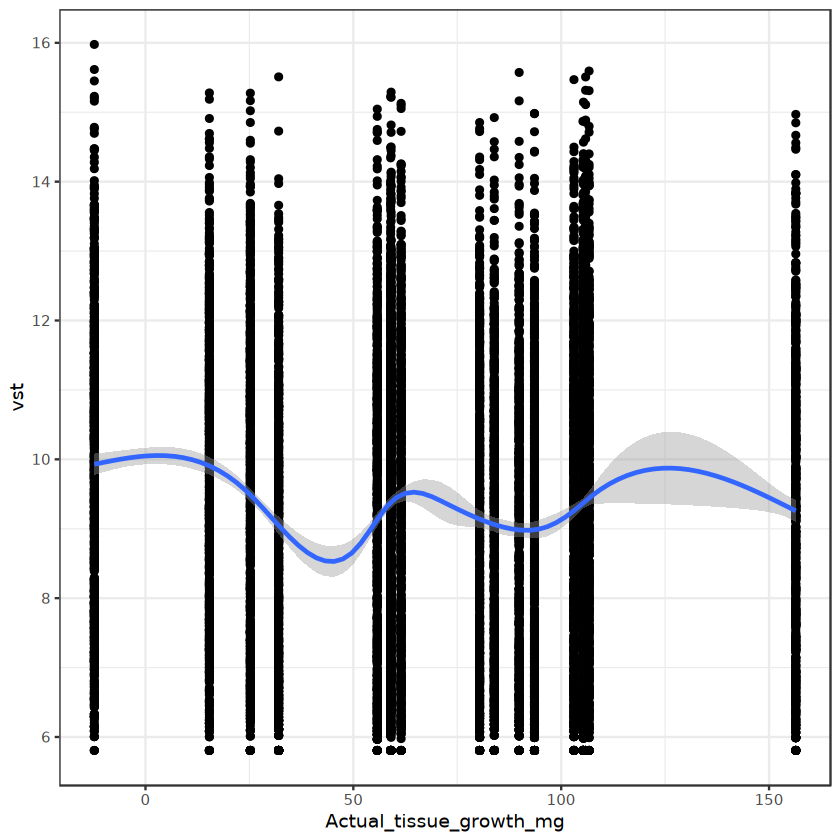

In [28]:
ggplot(red_vst_growth, aes(x = Actual_tissue_growth_mg, y = vst)) +
geom_point() +
geom_smooth() +
theme_bw()

what about pulling out just the hub gene?

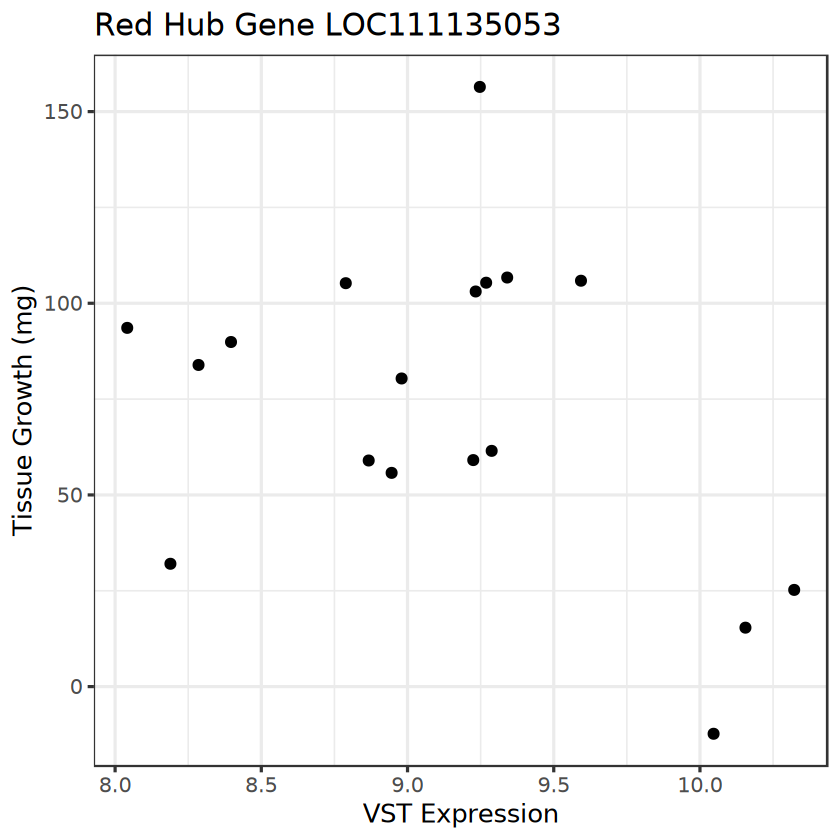

In [34]:
red_hubGene <- red_vst_growth %>% filter(Gene == 'LOC111135053')

ggplot(red_hubGene, aes(x = vst, y = Actual_tissue_growth_mg)) +
geom_point() +
labs(x = 'VST Expression',
     y = 'Tissue Growth (mg)',
     title = 'Red Hub Gene LOC111135053') +
theme_bw(base_size = 15)